### Step 3: Data Preprocessing, Applied EDA & Feature Engineering




Data Preview:
  category                                       cleaned_text  message_len  \
0      otp  never share your otp  or enter it on suspiciou...          157   
1   notifs  secure your accounts and cards your way with b...          279   
2      ads  this deals as hot as summer get gomo fiber and...          258   
3   notifs  gusto naming ready ka kausapin ang tropa you g...          306   
4      ads  need unstppbl data you can still get your favo...          194   

   has_url  
0        0  
1        0  
2        0  
3        0  
4        0  

Feature Analysis (Do they differ by category?):
          message_len  digit_count   has_url
category                                    
ads        277.595506    10.859551  0.191011
gov        153.493671     4.126582  0.189873
notifs     156.369094    11.826280  0.113189
otp        145.840156    10.493177  0.017544
spam       116.637209     7.311628  0.133333


C:\Users\Lyndon\AppData\Local\Temp\ipykernel_10116\1236106967.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


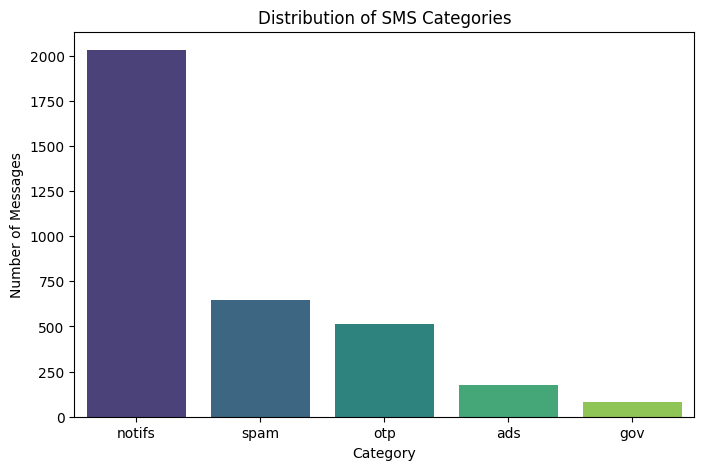

C:\Users\Lyndon\AppData\Local\Temp\ipykernel_10116\1236106967.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='message_len', data=df, palette='coolwarm')


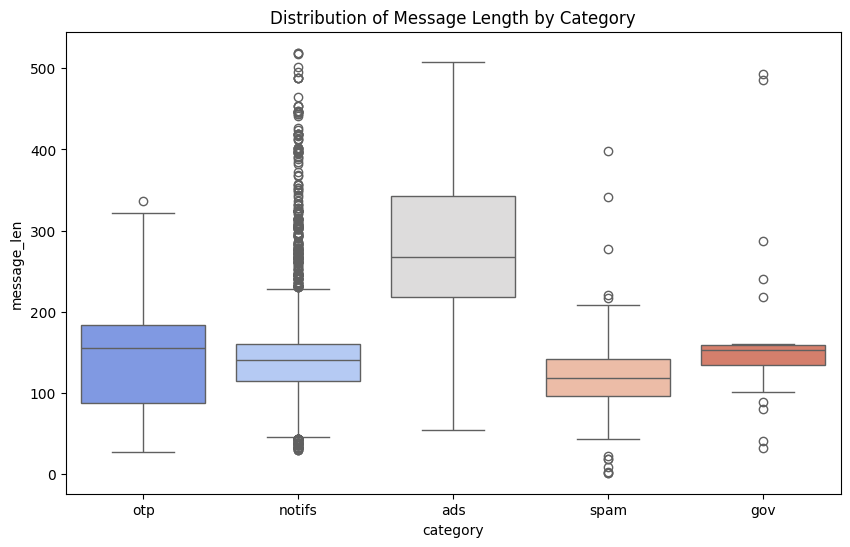

C:\Users\Lyndon\AppData\Local\Temp\ipykernel_10116\1236106967.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='has_url', data=df, palette='viridis')


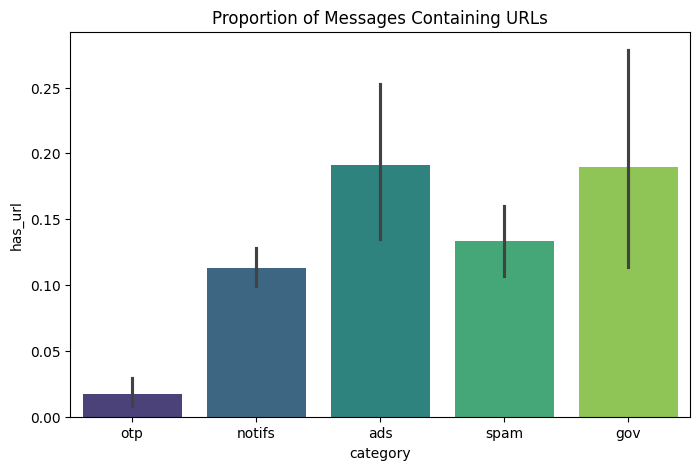

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# ---------------------------------------------------------
# 1. LOAD DATA & HANDLE DUPLICATES
# ---------------------------------------------------------
df = pd.read_excel('tagalog-sms.xlsx')

# Remove exact duplicates (common in SMS logs) to prevent model bias
df = df.drop_duplicates()
df['text'] = df['text'].astype(str) # Ensure text is treated as string

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING 
# ---------------------------------------------------------
# Message Length
df['message_len'] = df['text'].apply(len)

# Has URL?
df['has_url'] = df['text'].apply(lambda x: 1 if re.search(r'http|www', x, re.IGNORECASE) else 0)

# Digit Count
df['digit_count'] = df['text'].apply(lambda x: len(re.findall(r'\d', x)))

# ---------------------------------------------------------
# 3. TEXT PREPROCESSING 
# ---------------------------------------------------------
def clean_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Remove URLs
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    return text.strip()

df['cleaned_text'] = df['text'].apply(clean_text)

# ---------------------------------------------------------
# 4. EDA VISUALIZATION
# ---------------------------------------------------------
print("Data Preview:")
print(df[['category', 'cleaned_text', 'message_len', 'has_url']].head())

print("\nFeature Analysis (Do they differ by category?):")
print(df.groupby('category')[['message_len', 'digit_count', 'has_url']].mean())

# --- FIX: Calculate class_counts here ---
class_counts = df['category'].value_counts()

# Visualization 1: Class Balance
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of SMS Categories')
plt.xlabel('Category')
plt.ylabel('Number of Messages')
plt.show()

# Visualization 2: Message Length
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='message_len', data=df, palette='coolwarm')
plt.title('Distribution of Message Length by Category')
plt.show()

# Visualization 3: URL Presence
plt.figure(figsize=(8, 5))
sns.barplot(x='category', y='has_url', data=df, palette='viridis')
plt.title('Proportion of Messages Containing URLs')
plt.show()




⏳ Running PCA (Dimensionality Reduction)...


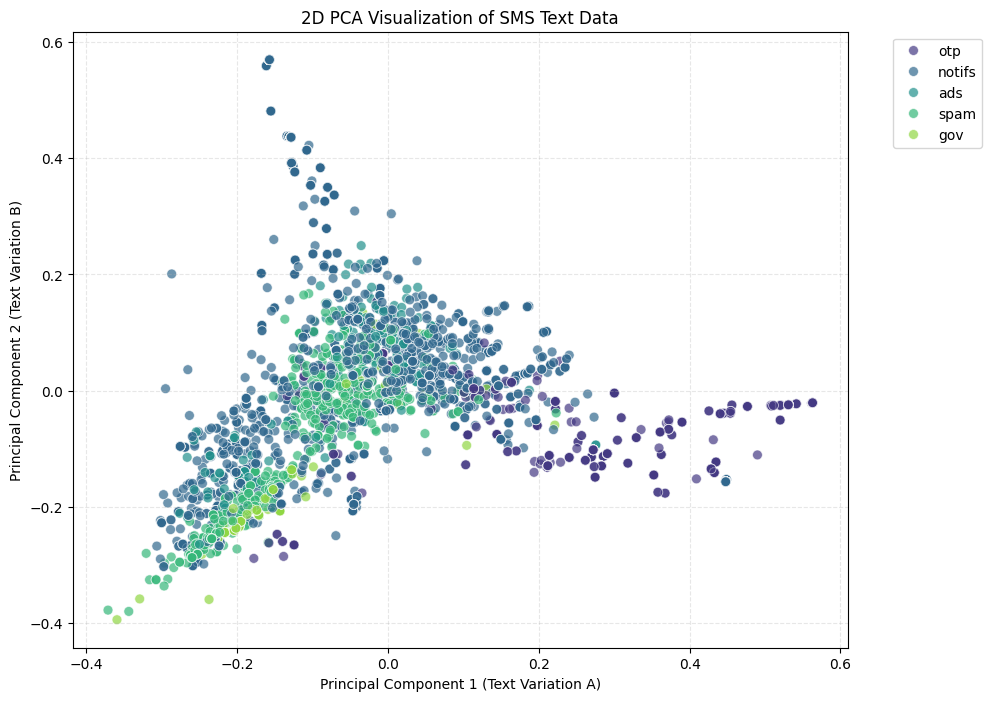

✅ PCA Plot Generated: Clusters indicate semantic similarity between messages.


In [28]:
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data for PCA
# We need to vectorize the text first (if not done already in this step)
tfidf_pca = TfidfVectorizer(max_features=1000) # Limit features for cleaner plot
X_vec = tfidf_pca.fit_transform(df['cleaned_text']).toarray()
y_labels = df['category']

# 2. Apply PCA (Reduce to 2 Dimensions)
print("⏳ Running PCA (Dimensionality Reduction)...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vec)

# 3. Create a DataFrame for Plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Category'] = y_labels.values

# 4. Plot the 2D Scatter Map
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Category', 
    data=pca_df, 
    palette='viridis',
    alpha=0.7,   # Transparency to see overlaps
    s=50         # Dot size
)

plt.title('2D PCA Visualization of SMS Text Data')
plt.xlabel('Principal Component 1 (Text Variation A)')
plt.ylabel('Principal Component 2 (Text Variation B)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print("✅ PCA Plot Generated: Clusters indicate semantic similarity between messages.")


### Step 4: Model Implementation

#### Training Multiple Models at Once

* Multinomial Naive Bayes: Serves as the probabilistic baseline, ideal for text and word count data.

* Logistic Regression: A highly interpretable linear model that helps explain which words lead to a certain classification.

* Support Vector Machine (SVM): A powerful linear model that excels in high-dimensional text data by finding the best separating hyperplane.

* Decision Tree: Provides simple, human-readable "if-then" rules to classify messages, though it can overfit.

* Random Forest: An ensemble that combines multiple Decision Trees to create a more robust and accurate model.

* Gradient Boosting (GBM): A sequential ensemble that builds on the mistakes of previous models, often yielding top-tier performance.

* K-Nearest Neighbors (KNN): A distance-based method that classifies new messages based on the majority class of their "neighbors."

* Multi-Layer Perceptron (MLP): A simple neural network that learns complex, non-linear patterns between words and categories.

* DistilBERT (Transformer): A modern, pre-trained Deep Learning model that understands the context and sequence of words (not just keywords), allowing it to detect subtle spam patterns that traditional models might miss.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. DEFINE X and y
X = df['cleaned_text']
y = df['category']

# 2. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. VECTORIZE (Create X_train_vec and X_test_vec)
tfidf = TfidfVectorizer(max_features=5000)

# Fit on TRAIN, transform on TEST (Crucial!)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("✅ Data Vectorized Successfully!")
print(f"X_train_vec shape: {X_train_vec.shape}")


✅ Data Vectorized Successfully!
X_train_vec shape: (2757, 4288)


🚀 Starting 8-Model Tournament (Tracking Accuracy & F1-Score)...
Training Naive Bayes... Done! (Acc: 0.8580 | F1: 0.8277)
Training Logistic Regression... Done! (Acc: 0.9232 | F1: 0.9159)
Training Decision Tree... Done! (Acc: 0.9232 | F1: 0.9227)
Training Random Forest... Done! (Acc: 0.9420 | F1: 0.9398)
Training Gradient Boosting... Done! (Acc: 0.9304 | F1: 0.9277)
Training Support Vector Machine... Done! (Acc: 0.9594 | F1: 0.9580)
Training K-Nearest Neighbors... Done! (Acc: 0.9290 | F1: 0.9283)
Training Neural Network (MLP)... Done! (Acc: 0.9667 | F1: 0.9660)

🏆 FINAL LEADERBOARD 🏆
                    Model  Accuracy  F1-Score  Time (s)
7    Neural Network (MLP)  0.966667  0.965978    7.5864
5  Support Vector Machine  0.959420  0.958020    2.6904
3           Random Forest  0.942029  0.939808    0.7326
6     K-Nearest Neighbors  0.928986  0.928313    0.0606
4       Gradient Boosting  0.930435  0.927713    7.0532
2           Decision Tree  0.923188  0.922728    0.2444
1     Logistic Regr

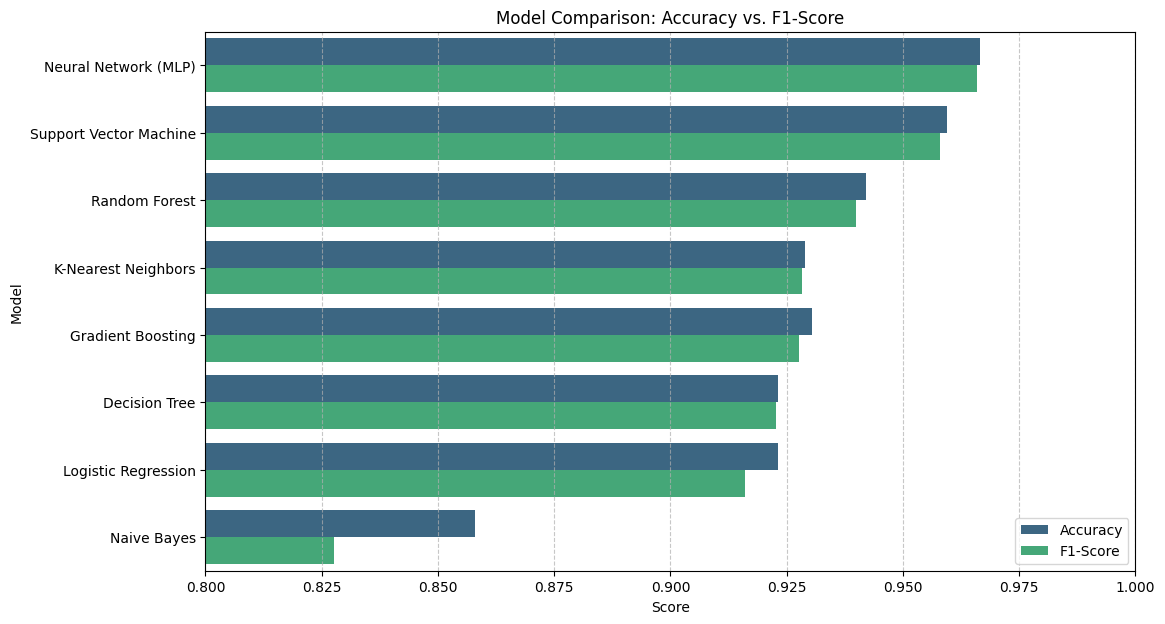

In [30]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score # Import F1
import time 

# 1. DEFINE 8 MODELS
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(kernel='linear', probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

# 2. TRAIN LOOP
results = []
print("🚀 Starting 8-Model Tournament (Tracking Accuracy & F1-Score)...")

for name, model in models.items():
    print(f"Training {name}...", end=" ")
    start_time = time.time()
    
    # Train & Predict
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted') # Weighted F1 for imbalance
    elapsed = time.time() - start_time
    
    results.append({
        "Model": name, 
        "Accuracy": acc, 
        "F1-Score": f1,
        "Time (s)": round(elapsed, 4)
    })
    print(f"Done! (Acc: {acc:.4f} | F1: {f1:.4f})")

# 3. RESULTS DATAFRAME
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

print("\n🏆 FINAL LEADERBOARD 🏆")
print(results_df)

# 4. VISUALIZATION (Side-by-Side Bars)
# We need to "melt" the dataframe to make it suitable for seaborn grouped bar chart
melted_df = results_df.melt(id_vars="Model", value_vars=["Accuracy", "F1-Score"], 
                            var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
sns.barplot(x="Score", y="Model", hue="Metric", data=melted_df, palette="viridis")
plt.title("Model Comparison: Accuracy vs. F1-Score")
plt.xlim(0.8, 1.0) # Zoom in on the top range
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## 3. DistilBERT (Transformer) (CPU)

In [6]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # Force CPU
os.environ["WANDB_DISABLED"] = "true"    # Disable Weights&Biases logging

import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score

print("🤖 Initializing BERT Pipeline (CPU Mode)...")

# 2. PREPARE DATA
label_list = sorted(list(set(y)))
label_map = {label: i for i, label in enumerate(label_list)}

train_texts_bert = X_train.tolist()
val_texts_bert = X_test.tolist()
train_labels_bert = [label_map[label] for label in y_train]
val_labels_bert = [label_map[label] for label in y_test]

# 3. TOKENIZE
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_encodings = tokenizer(train_texts_bert, truncation=True, padding=True)
val_encodings = tokenizer(val_texts_bert, truncation=True, padding=True)

class SMSDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = SMSDataset(train_encodings, train_labels_bert)
val_dataset = SMSDataset(val_encodings, val_labels_bert)

# 4. LOAD MODEL
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=len(label_map))

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# 5. TRAINING ARGUMENTS (Reduced batch size to prevent freezing)
training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=2,              # Reduced to 2 epochs for speed
    per_device_train_batch_size=4,   # Small batch size for safety
    per_device_eval_batch_size=8,
    logging_steps=10,
    eval_strategy="epoch",           
    save_strategy="no",
    use_cpu=True                     # Explicitly tell Trainer to use CPU
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\n🏋️ Training BERT... (This might take 10-15 mins)...")
trainer.train()

# 6. RESULTS
print("\n--- BERT RESULTS ---")
metrics = trainer.evaluate()
print(f"Accuracy: {metrics['eval_accuracy']:.4f}")
print(f"F1-Score: {metrics['eval_f1']:.4f}")


c:\Users\Lyndon\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🤖 Initializing BERT Pipeline (CPU Mode)...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).



🏋️ Training BERT... (This might take 10-15 mins)...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.186100,0.406576,0.913043,0.912152
2,0.103300,0.239958,0.953623,0.952784



--- BERT RESULTS ---


Accuracy: 0.9536
F1-Score: 0.9528


## 3. DistilBERT (Transformer) (GPU)

In [ ]:
import os
import torch
import sys
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score

# 1. SETUP GPU
if not torch.cuda.is_available():
    print("❌ ERROR: PyTorch cannot find your GPU.")
    print("   You are likely running on CPU which is why it takes 15 minutes.")
    print("   Please fix your PyTorch install (install cu128 nightly) before continuing.")
    sys.exit() # Stop the script so you don't waste time

device = torch.device("cuda")
print(f"🚀 Training on: {device} (Name: {torch.cuda.get_device_name(0)})")

os.environ["WANDB_DISABLED"] = "true" 

# 2. PREPARE DATA (Assumes X_train, etc. are already loaded in memory)
label_list = sorted(list(set(y)))
label_map = {label: i for i, label in enumerate(label_list)}

train_texts_bert = X_train.tolist()
val_texts_bert = X_test.tolist()
train_labels_bert = [label_map[label] for label in y_train]
val_labels_bert = [label_map[label] for label in y_test]

# 3. TOKENIZE
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_encodings = tokenizer(train_texts_bert, truncation=True, padding=True)
val_encodings = tokenizer(val_texts_bert, truncation=True, padding=True)

class SMSDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = SMSDataset(train_encodings, train_labels_bert)
val_dataset = SMSDataset(val_encodings, val_labels_bert)

# 4. LOAD MODEL
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=len(label_map))
model.to(device) 

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# 5. TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir='./bert_results_gpu',
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=64,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="no",
    fp16=True, 
    dataloader_num_workers=0 
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\n🏎️ STARTING GPU TRAINING...")
trainer.train()

# 6. RESULTS
print("\n--- BERT GPU RESULTS ---")
metrics = trainer.evaluate()
print(f"Accuracy: {metrics['eval_accuracy']:.4f}")
print(f"F1-Score: {metrics['eval_f1']:.4f}")

🚀 Training on: cuda (Name: NVIDIA GeForce RTX 5080)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).



🏎️ STARTING GPU TRAINING...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.455400,0.420285,0.863768,0.834263
2,0.270700,0.275876,0.930435,0.926326
3,0.092100,0.208482,0.937681,0.935621
4,0.057000,0.199201,0.956522,0.955050
5,0.059500,0.191841,0.953623,0.952242



--- BERT GPU RESULTS ---


Accuracy: 0.9536
F1-Score: 0.9522


### Testing The Model with new SMS messages

In [42]:
import joblib
from lime.lime_text import LimeTextExplainer 
from sklearn.pipeline import make_pipeline

# 1. SELECT THE WINNER (MLP)
final_model = models["Neural Network (MLP)"]

# 2. DEFINE PREDICTION FUNCTION
def predict_sms(text):
    # A. Feature Engineering (For Report consistency, though not used in training)
    msg_len = len(text)
    has_url = 1 if re.search(r'http|www', text, re.IGNORECASE) else 0
    digit_count = len(re.findall(r'\d', text))
    
    # B. Clean Text
    cleaned = clean_text(text)
    
    # C. Vectorize & Predict
    vec_text = tfidf.transform([cleaned])
    prediction = final_model.predict(vec_text)[0]
    probabilities = final_model.predict_proba(vec_text)[0]
    confidence = max(probabilities) * 100
    
    return {
        "Original": text,
        "Prediction": prediction.upper(),
        "Confidence": f"{confidence:.2f}%",
        "Type": "🔔 Notifs/OTP" if prediction in ['notifs', 'otp'] else "🚨 SPAM/AD"
    }

# 3. TEST CASES
test_messages = [
    "Your OTP is 8291. Do not share this with anyone.", 
    "Congrats! You won 500k php from shopee! Click here: http://bit.ly/scam now!", 
    "Gusto mo ba ng extra income? Text me at 09123456789.", 
    "BDO: Your account has been compromised. Visit www.bdo-verify.com to unlock.", 
    "Hi mom, pauwi na ako. luto ka sinigang." ,
    "Hello, testing this message with no spam content.",
]

print("🧪 MANUAL TESTING RESULTS (MLP Model)\n" + "-"*60)

for msg in test_messages:
    result = predict_sms(msg)
    print(f"📝 Text:  {result['Original']}")
    print(f"🤖 Pred:  {result['Prediction']} ({result['Confidence']})")
    print(f"🏷️ Type:  {result['Type']}")
    print("-" * 60)

# ---------------------------------------------------------
# 4. EXPLAINABILITY (LIME Analysis) - MULTIPLE EXAMPLES
# ---------------------------------------------------------
print("\n🔍 LIME EXPLAINABILITY ANALYSIS")

# 1. Setup the Pipeline function (Connects text -> clean -> vector -> model)
def predict_proba_pipeline(texts):
    cleaned_texts = [clean_text(t) for t in texts]
    vec_texts = tfidf.transform(cleaned_texts)
    return final_model.predict_proba(vec_texts)

# 2. Initialize Explainer
explainer = LimeTextExplainer(class_names=final_model.classes_)

# 3. Select which messages to analyze from your 'test_messages' list
# Index 1 = Shopee Scam
# Index 3 = BDO Phishing
# Index 4 = "Hi mom" (Safe message)
indices_to_show = [1, 3, 4] 

for i in indices_to_show:
    current_msg = test_messages[i]
    print("="*60)
    print(f"Analyzing Example #{i+1}:")
    print(f"Message: \"{current_msg}\"")
    
    # Generate Explanation
    exp = explainer.explain_instance(
        current_msg, 
        predict_proba_pipeline, 
        num_features=6 
    )
    
    # Show the visualization
    # In Jupyter, this renders the colorful bar chart immediately below the print statements
    exp.show_in_notebook(text=True)
    print("\n") # Add space between charts


🧪 MANUAL TESTING RESULTS (MLP Model)
------------------------------------------------------------
📝 Text:  Your OTP is 8291. Do not share this with anyone.
🤖 Pred:  OTP (82.61%)
🏷️ Type:  🔔 Notifs/OTP
------------------------------------------------------------
📝 Text:  Congrats! You won 500k php from shopee! Click here: http://bit.ly/scam now!
🤖 Pred:  SPAM (99.29%)
🏷️ Type:  🚨 SPAM/AD
------------------------------------------------------------
📝 Text:  Gusto mo ba ng extra income? Text me at 09123456789.
🤖 Pred:  SPAM (93.73%)
🏷️ Type:  🚨 SPAM/AD
------------------------------------------------------------
📝 Text:  BDO: Your account has been compromised. Visit www.bdo-verify.com to unlock.
🤖 Pred:  NOTIFS (98.99%)
🏷️ Type:  🔔 Notifs/OTP
------------------------------------------------------------
📝 Text:  Hi mom, pauwi na ako. luto ka sinigang.
🤖 Pred:  SPAM (78.45%)
🏷️ Type:  🚨 SPAM/AD
------------------------------------------------------------
📝 Text:  Hello, testing this message



Analyzing Example #4:
Message: "BDO: Your account has been compromised. Visit www.bdo-verify.com to unlock."




Analyzing Example #5:
Message: "Hi mom, pauwi na ako. luto ka sinigang."


## Saving The Model

In [ ]:
import joblib
import os

# 1. Select the MLP Model (Your Winner)
final_model = models["Neural Network (MLP)"]

# 2. Create the 'models' folder if it doesn't exist
folder_path = 'models'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"📂 Created folder: {folder_path}")

# 3. Save the Model
joblib.dump(final_model, 'models/spam_mlp_model.pkl')

# 4. Save the Vectorizer (CRITICAL!)
joblib.dump(tfidf, '    ')

print("✅ Model saved to: models/spam_mlp_model.pkl")
print("✅ Vectorizer saved to: models/vectorizer.pkl")


✅ Model saved to: models/spam_mlp_model.pkl
✅ Vectorizer saved to: models/vectorizer.pkl
